In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = sns.load_dataset('mpg')
df = df.dropna()
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
X = df[['cylinders','horsepower','weight','displacement']]
y = df['mpg']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

rmse_lin, r2_lin

(np.float64(4.2298860753856395), 0.6494566661462682)

In [7]:
poly2 = Pipeline([('poly', PolynomialFeatures(degree=2)),
                  ('model', LinearRegression())
                  ])
poly3 = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('model', LinearRegression())
                  ])

poly2.fit(X_train, y_train)
poly3.fit(X_train, y_train)

pred2 = poly2.predict(X_test)
pred3 = poly3.predict(X_test)

rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))

r2_2 = r2_score(y_test, pred2)
r2_3 = r2_score(y_test, pred3)

rmse2, rmse3, r2_2, r2_3


(np.float64(4.13359368305332),
 np.float64(4.1522301561777555),
 0.6652350805577634,
 0.6622096736464055)

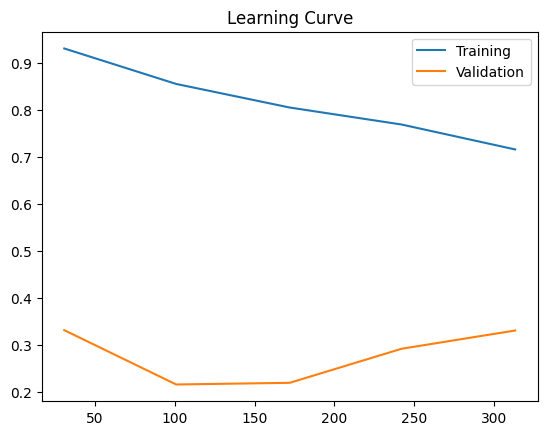

In [10]:
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Training')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.legend()
plt.title('Learning Curve')
plt.show()

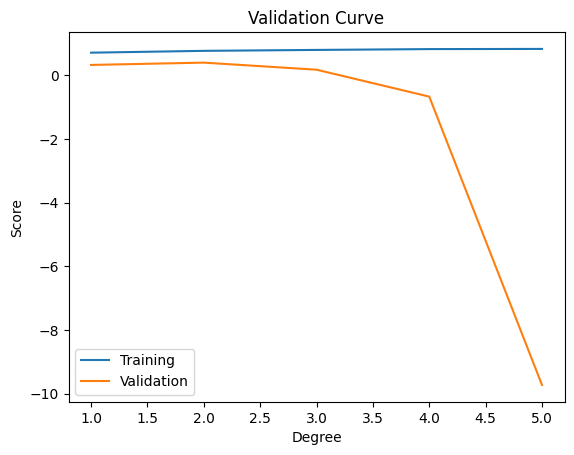

In [11]:
degrees = [1, 2, 3, 4, 5]
train_scores, val_scores = validation_curve(
    Pipeline([('poly', PolynomialFeatures()), ('model', LinearRegression())]),
    X, y, param_name='poly__degree', param_range=degrees, cv=5)

plt.plot(degrees, train_scores.mean(axis=1), label='Training')
plt.plot(degrees, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Degree')
plt.ylabel('Score')
plt.title('Validation Curve')
plt.legend()
plt.show()

We started by loading the mpg dataset from seaborn, cleaned it by dropping missing values, and then split the data into training and testing sets. We then trained and evaluated three different regression models: a simple Linear Regression model, a Polynomial Regression model with degree 2, and another Polynomial Regression model with degree 3. Finally, we visualized the model performance using learning curves and validation curves to understand how model complexity affects performance and to identify potential overfitting or underfitting. Based on these metrics, the Polynomial Regression model with degree 2 appears to be the best performing among the three, as it has the lowest RMSE and the highest R-squared on the test set. Increasing the complexity to degree 3 did not yield better results and might indicate diminishing returns or the beginning of overfitting.